### **라이브러리 호출 및 데이터 로드**

In [163]:
# 라이브러리 호출
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import platform
import ast
from collections import Counter
import json
from pprint import pprint

warnings.filterwarnings('ignore')

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 컬럼 너비 제한 해제
pd.set_option('display.max_colwidth', None)

In [164]:
# 통계용 라이브러리 호출
from scipy import stats
import scikit_posthocs as sp

#### User-level 데이터 재구성 사유

- `explode` 과정에서 하나의 관측치가 여러 행으로 분할되어 **표본 수가 과대 증가**
- 동일 게임/유저 기반 데이터가 반복되며 **독립성 가정 위반**
- 이로 인해 **통계 검정 결과(p-value)가 왜곡될 가능성 존재**

따라서, User-level 데이터는 `explode` 없이 원본 구조를 유지하고,
분석은 **Game-level 기준으로 수행**하여 신뢰도를 확보함.

### **데이터 로드**

In [165]:
# 데이터 로드
# 챔피언단위 -stats
df_champion = pd.read_csv('../실전 프로젝트 코드 파일_6조/data/유저단위_게임데이터_상위랭커보존-stats_champion_1.csv')

#시너지단위
df_combination = pd.read_csv('../실전 프로젝트 코드 파일_6조/data/유저단위_게임데이터_상위랭커보존-stats_combination_1.csv')

#아이템단위
df_items = pd.read_csv('../실전 프로젝트 코드 파일_6조/data/유저단위_게임데이터_상위랭커보존-stats_champion_items_1.csv')

In [166]:
df_champion.head(2)

,user_id,game_id,user_tier,ranked,flag_1,flag_2,active_synergies,top4_flag,ranked_1,champions
0,KR-USER-1,KR_4291707834,platinum,5,0,0,{},False,False,"[{'name': 'ziggs', 'star': 1, 'cost': 1, 'origin': 'Rebel', 'class': ""['Demolitionist']""}, {'name': 'ashe', 'star': 1, 'cost': 3, 'origin': 'Celestial', 'class': ""['Sniper']""}, {'name': 'chogath', 'star': 1, 'cost': 4, 'origin': 'Void', 'class': ""['Brawler']""}, {'name': 'ekko', 'star': 1, 'cost': 5, 'origin': 'Cybernetic', 'class': ""['Infiltrator']""}]"
1,KR-USER-10,KR_4291614366,platinum,2,0,0,"{'Chrono': 4, 'DarkStar': 3, 'Brawler': 2, 'Sniper': 2}",True,False,"[{'name': 'malphite', 'star': 2, 'cost': 1, 'origin': 'Rebel', 'class': ""['Brawler']""}, {'name': 'caitlyn', 'star': 2, 'cost': 1, 'origin': 'Chrono', 'class': ""['Sniper']""}, {'name': 'blitzcrank', 'star': 2, 'cost': 2, 'origin': 'Chrono', 'class': ""['Brawler']""}, {'name': 'shen', 'star': 2, 'cost': 2, 'origin': 'Chrono', 'class': ""['Blademaster']""}, {'name': 'shaco', 'star': 2, 'cost': 3, 'origin': 'Dark Star', 'class': ""['Infiltrator']""}, {'name': 'lux', 'star': 1, 'cost': 3, 'origin': 'Dark Star', 'class': ""['Sorcerer']""}, {'name': 'wukong', 'star': 2, 'cost': 4, 'origin': 'Chrono', 'class': ""['Vanguard']""}, {'name': 'jhin', 'star': 2, 'cost': 4, 'origin': 'Dark Star', 'class': ""['Sniper']""}]"


In [167]:
df_champion.info()

<class 'pandas.DataFrame'>
RangeIndex: 396204 entries, 0 to 396203
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   user_id           396204 non-null  str  
 1   game_id           396204 non-null  str  
 2   user_tier         396204 non-null  str  
 3   ranked            396204 non-null  int64
 4   flag_1            396204 non-null  int64
 5   flag_2            396204 non-null  int64
 6   active_synergies  396204 non-null  str  
 7   top4_flag         396204 non-null  bool 
 8   ranked_1          396204 non-null  bool 
 9   champions         396204 non-null  str  
dtypes: bool(2), int64(3), str(5)
memory usage: 24.9 MB


In [168]:
df_combination.head(2)

,gameid,user_tier,ranked,user_id,flag_1,flag_2,active_synergies,top4_flag,ranked_1,combination_rebuild
0,KR_4291707834,platinum,5,KR-USER-1,0,0,{},False,False,"{'Cybernetic': 1, 'Demolitionist': 1, 'Infiltrator': 1, 'Rebel': 1, 'Brawler': 1, 'Celestial': 1, 'Void': 1, 'Sniper': 1}"
1,KR_4291707834,platinum,3,KR-USER-2,0,0,"{'Cybernetic': 3, 'Vanguard': 2}",True,False,"{'Blaster': 1, 'Chrono': 1, 'Cybernetic': 4, 'Demolitionist': 1, 'Rebel': 1, 'Blademaster': 2, 'Brawler': 1, 'Sorcerer': 1, 'Void': 1, 'Valkyrie': 1, 'Vanguard': 2}"


In [169]:
df_items.head(2)

,gameid,user_tier,ranked,champion,item_count,champion_count
0,KR_4291707834,platinum,5,"{'Ziggs': {'items': [7], 'star': 1}, 'Ashe': {'items': [9], 'star': 1}, 'ChoGath': {'items': [6], 'star': 1}, 'Ekko': {'items': [1], 'star': 1}}",4,4
1,KR_4291707834,platinum,3,"{'Ziggs': {'items': [24], 'star': 3}, 'Fiora': {'items': [37], 'star': 2}, 'Leona': {'items': [36, 24], 'star': 2}, 'Lucian': {'items': [], 'star': 2}, 'Vi': {'items': [5], 'star': 2}, 'Kayle': {'items': [], 'star': 2}, 'WuKong': {'items': [3, 67], 'star': 2}, 'VelKoz': {'items': [4], 'star': 2}}",8,8


---
### EDA & 통계

##### **1. 시너지에 따라 순방률 차이가 존재하는가?**


In [170]:
df = df_combination.copy()

# 1. 문자열 → dict 변환
df['active_synergies'] = df['active_synergies'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# 2️. dict만 처리
df['synergy_list'] = df['active_synergies'].apply(
    lambda x: list(x.items()) if isinstance(x, dict) else []
)

# 3️. explode
df_exploded = df.explode('synergy_list')

# 4️. None 제거
df_exploded = df_exploded[df_exploded['synergy_list'].notnull()]

# 5️. 튜플만 남기기
df_exploded = df_exploded[
    df_exploded['synergy_list'].apply(lambda x: isinstance(x, tuple))
]

# 6️. 안전하게 분리
df_exploded['synergy'] = df_exploded['synergy_list'].apply(lambda x: x[0])
df_exploded['value'] = df_exploded['synergy_list'].apply(lambda x: x[1])

# 7️. 최종 데이터
df_final = df_exploded[['gameid', 'synergy', 'value', 'top4_flag', 'user_tier']]

In [171]:
df_final.head(1)

,gameid,synergy,value,top4_flag,user_tier
1,KR_4291707834,Cybernetic,3,True,platinum


In [172]:
# 시너지별 순방률 계산
df_final.groupby('synergy')['top4_flag'].mean().sort_values(ascending=False)

synergy
Starship         0.688598
Mercenary        0.605626
Valkyrie         0.603229
Mystic           0.589717
Rebel            0.586192
Demolitionist    0.571093
ManaReaver       0.560546
Chrono           0.548607
Blaster          0.545081
Void             0.543779
Celestial        0.538247
Infiltrator      0.537487
Sorcerer         0.536631
Brawler          0.532792
DarkStar         0.530779
Sniper           0.530638
Protector        0.530285
MechPilot        0.521824
Blademaster      0.513547
Cybernetic       0.506384
StarGuardian     0.505226
Vanguard         0.488986
SpacePirate      0.480953
Name: top4_flag, dtype: float64

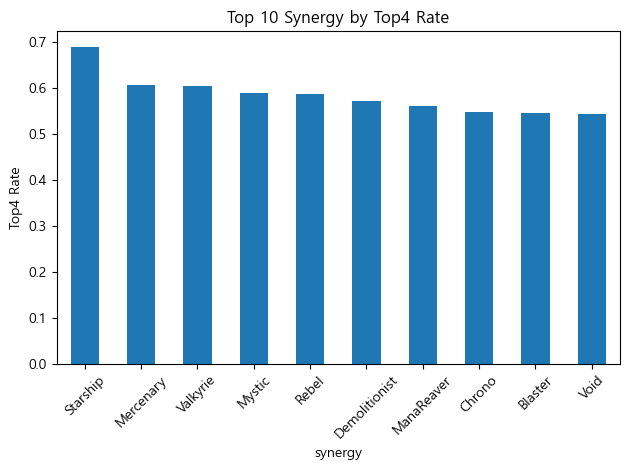

In [173]:
# top 10 시너지별 순방률 그래프
top_synergy = df_final.groupby('synergy')['top4_flag'].mean().sort_values(ascending=False).head(10)

plt.figure()
top_synergy.plot(kind='bar')
plt.title('Top 10 Synergy by Top4 Rate')
plt.ylabel('Top4 Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

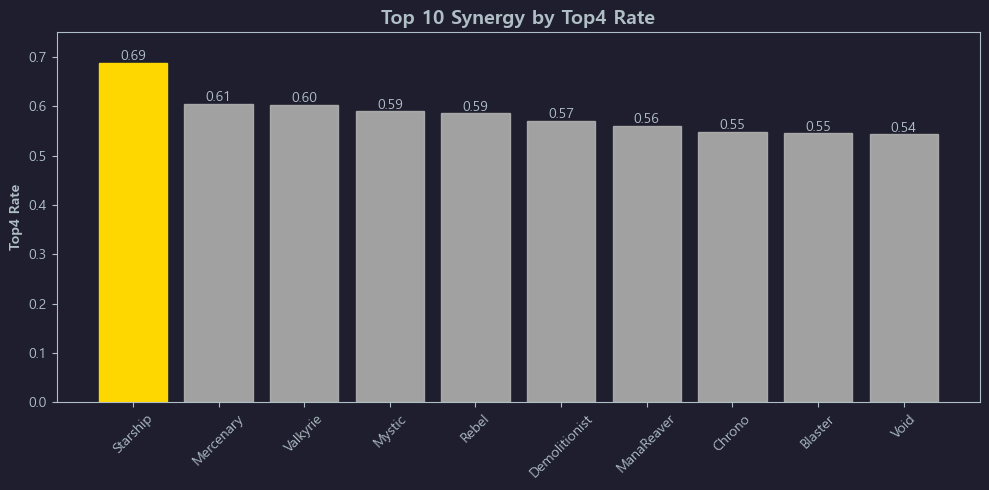

In [174]:
# 시각화 2 - 그래프 변경 및 강조
top_synergy = df_final.groupby('synergy')['top4_flag'].mean().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))

# 배경색 설정
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

bars = ax.bar(top_synergy.index, top_synergy.values)

# 1등 강조
bars[0].set_color('#FFD700')

# 나머지 (연한 회색)
for i in range(1, len(bars)):
    bars[i].set_color("#b3b3b3e1")

# 글씨색 변경
ax.set_title('Top 10 Synergy by Top4 Rate', fontsize=14, color='#b0bec5', fontweight='bold')
ax.set_ylabel('Top4 Rate', color='#b0bec5', fontweight='bold')
ax.tick_params(colors='#b0bec5')
ax.spines[:].set_color('#b0bec5')
plt.xticks(rotation=45)

# 값 표시
for i, v in enumerate(top_synergy.values):
    ax.text(i, v + 0.005, f"{v:.2f}", ha='center', color='#b0bec5')

ax.set_ylim(0, 0.75)

plt.tight_layout()
plt.show()

In [175]:
display(df_final.head(1))
print(df_final.shape)

,gameid,synergy,value,top4_flag,user_tier
1,KR_4291707834,Cybernetic,3,True,platinum


(1772641, 5)


#### **(1) 카이제곱 독립성 검점**
- Cochran's rule 만족 여부 확인 후, 독립성 검정 수행 예정

In [176]:
# df_final의 인덱스 초기화
df_final_1 = df_final.reset_index(drop=True)

# 가설 설정
print("[가설 설정]")
print(f"H₀: 시너지와 top4 여부에는 유의한 차이가 없다.")
print(f"H₁: 시너지와 top4 여부에는 유의한 차이가 있다.")

# Cochran's rule 만족 여부 확인
# 교차표 제작
ct_synergy_top4 = pd.crosstab(df_final_1['top4_flag'], df_final_1['synergy'])
# display(ct_synergy_top4)

# 기대빈도 계산
    # chi2_sy: 카이제곱 통계량
    # dof_sy: 자유도
    # expected_sy: 기대빈도
chi2_sy, p_val_sy, dof_sy, expected_sy = stats.chi2_contingency(ct_synergy_top4)

# Cochran's rule 확인
under5_cells_cnt = (expected_sy < 5).sum().sum()
under1_cells_cnt = (expected_sy < 1).sum().sum()
total_cells_cnt = expected_sy.size
under5_cells_pct = (under5_cells_cnt / total_cells_cnt)*100

print(f"\n[Cochran's rule 점검 결과]")
print(f" 기대빈도가 5보다 낮은 셀이 전체의 {under5_cells_pct}% 이고, 기대빈도가 1보다 낮은 셀은 {under1_cells_cnt}개이다.")
print(f"따라서 Cochran's rule을 {'만족한다.' if (under5_cells_pct <= 20 and under1_cells_cnt == 0) else '만족하지 않는다.'}")

[가설 설정]
H₀: 시너지와 top4 여부에는 유의한 차이가 없다.
H₁: 시너지와 top4 여부에는 유의한 차이가 있다.

[Cochran's rule 점검 결과]
 기대빈도가 5보다 낮은 셀이 전체의 0.0% 이고, 기대빈도가 1보다 낮은 셀은 0개이다.
따라서 Cochran's rule을 만족한다.


In [177]:
# 카이제곱 독립성 검정
print(f'\n[카이제곱 검정 결과]')
print(f'chi2={chi2_sy:.4f}, p={p_val_sy:.4e}, dof={dof_sy}')

# 결론
print(f"\n[결론 (α=0.05)]")
alpha = 0.05
if p_val_sy < alpha:
    print('p-value가 유의수준보다 낮으므로 시너지와 top4 여부는 유의미한 관계가 있음')
else:
    print('p-value가 유의수준보다 높으므로 시너지와 top4 여부는 유의미한 관계가 없음')


[카이제곱 검정 결과]
chi2=8906.2153, p=0.0000e+00, dof=22

[결론 (α=0.05)]
p-value가 유의수준보다 낮으므로 시너지와 top4 여부는 유의미한 관계가 있음


In [178]:
from scipy.stats.contingency import association 

# 효과크기 계산 - Cramér's V
r_sy, c_sy = ct_synergy_top4.shape
df_star_sy = min(r_sy-1, c_sy-1) # 효과크기 해석 기준을 정하기 위해 필요함

cramers_v_sy = association(ct_synergy_top4, method='cramer')

print(f"Cramér's V = {cramers_v_sy:.3f}")
print(f"df* = {df_star_sy}")

# Cramér's V 해석 기준 (df*에 따라 계산)
if cramers_v_sy < (0.1 / np.sqrt(df_star_sy)):
    answer = '효과크기는 매우 작은 편이다.'
elif cramers_v_sy < (0.3 / np.sqrt(df_star_sy)):
    answer = '효과크기는 작은 편이다.'
elif cramers_v_sy < (0.5 / np.sqrt(df_star_sy)):
    answer = '효과크기는 중간인 편이다.'
elif cramers_v_sy >= (0.5 / np.sqrt(df_star_sy)):
    answer = '효과크기는 큰 편이다.'
    
print(f"-> df*의 값이 {df_star_sy}이므로, cramer's 효과크기가 {cramers_v_sy:.3f}라면 {answer}")

Cramér's V = 0.071
df* = 1
-> df*의 값이 1이므로, cramer's 효과크기가 0.071라면 효과크기는 매우 작은 편이다.


In [179]:
# 조정된 잔차 분석 - 어느 셀이 기대와 다른가?
from statsmodels.stats.contingency_tables import Table

print(f"[조정된 잔차]")

table = Table(ct_synergy_top4)
std_res_sy = pd.DataFrame(table.standardized_resids, index=ct_synergy_top4.index, columns=ct_synergy_top4.columns)
display(std_res_sy)

[조정된 잔차]


synergy,Blademaster,Blaster,Brawler,Celestial,Chrono,Cybernetic,DarkStar,Demolitionist,Infiltrator,ManaReaver,...,Protector,Rebel,Sniper,Sorcerer,SpacePirate,StarGuardian,Starship,Valkyrie,Vanguard,Void
top4_flag,,,,,,,,,,,,,,,,,,,,,
False,22.030129,1.03961,9.047539,6.433387,-1.959858,16.667219,7.044474,-10.706317,4.812772,-9.778526,...,7.922789,-17.224714,8.823734,6.45797,26.650402,18.04397,-43.668491,-31.168956,33.71739,0.778961
True,-22.030129,-1.03961,-9.047539,-6.433387,1.959858,-16.667219,-7.044474,10.706317,-4.812772,9.778526,...,-7.922789,17.224714,-8.823734,-6.45797,-26.650402,-18.04397,43.668491,31.168956,-33.71739,-0.778961


In [180]:
# 조정된 잔차 해석
# 해석기준으로 1.96을 선정한 이유: 조정된 잔차는 표준정규분포를 따르므로 잔차가 |1.96| 미만이라면 95% 신뢰구간 내에 포함되기 때문이다. 

# 조정된 잔차 해석 결과를 표로 정리
threshold = 1.96

results_sy = []
for top4 in std_res_sy.index:
    for synergy in std_res_sy.columns:
        residual = std_res_sy.loc[top4, synergy]
        top4_label = 'top4 진입' if top4 == 1 else 'top4 미진입'

        if residual > threshold:
            interpretation1 = '기대빈도보다 실제 빈도가 유의미하게 높음'
        elif residual < -threshold:
            interpretation1 = '기대빈도보다 실제 빈도가 유의미하게 낮음'
        else:
            interpretation1 = '유의미한 차이 없음'

        results_sy.append({
            'synergy': synergy,
            'top4': top4_label,
            'residual': round(residual, 3),
            '해석': interpretation1
        })

results_df_sy = pd.DataFrame(results_sy)
display(results_df_sy)

,synergy,top4,residual,해석
0,Blademaster,top4 미진입,22.030,기대빈도보다 실제 빈도가 유의미하게 높음
1,Blaster,top4 미진입,1.040,유의미한 차이 없음
2,Brawler,top4 미진입,9.048,기대빈도보다 실제 빈도가 유의미하게 높음
3,Celestial,top4 미진입,6.433,기대빈도보다 실제 빈도가 유의미하게 높음
4,Chrono,top4 미진입,-1.960,유의미한 차이 없음
5,Cybernetic,top4 미진입,16.667,기대빈도보다 실제 빈도가 유의미하게 높음
6,DarkStar,top4 미진입,7.044,기대빈도보다 실제 빈도가 유의미하게 높음
7,Demolitionist,top4 미진입,-10.706,기대빈도보다 실제 빈도가 유의미하게 낮음
8,Infiltrator,top4 미진입,4.813,기대빈도보다 실제 빈도가 유의미하게 높음
9,ManaReaver,top4 미진입,-9.779,기대빈도보다 실제 빈도가 유의미하게 낮음


[해석 방법]
- 예를 들어 `Starship x top4 진입`이라는 행을 보면 `기대빈도보다 실제 빈도가 유의미하게 높음`이라는 결과가 나왔다. 이는 Starship을 가진 유저가 top4에 진입한 횟수가 기대값보다 많다는 것이다.
- 반대로 `기대빈도보다 실제 빈도가 유의미하게 낮음`은 해당 시너지를 가진 유저가 top4에 진입한 횟수가 기대값보다 적다는 것이다.
- 잔차의 절댓값이 클수록 기대빈도와의 차이가 크다는 것을 의미한다.

---
### **2. 티어에 따라 순방률 차이가 존재하는가?**

In [181]:
# user_tier에 따른 순방률 계산
tier_stats = df_final.groupby('user_tier')['top4_flag'].mean().sort_values(ascending=False)
print(tier_stats)

user_tier
platinum        0.552160
diamond         0.548846
master          0.545221
grand_master    0.543642
challenger      0.543490
Name: top4_flag, dtype: float64


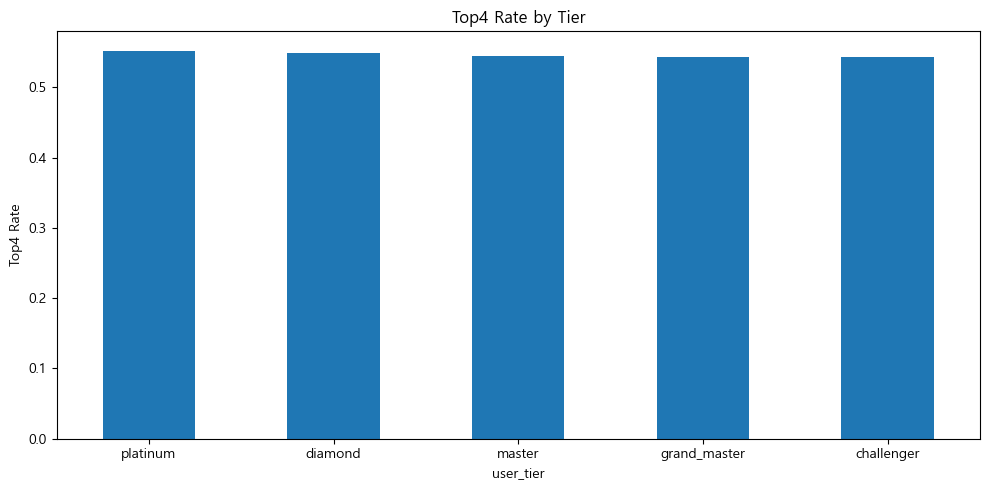

In [182]:
# 시각화
plt.figure(figsize=(10,5))
tier_stats.plot(kind='bar')

plt.title('Top4 Rate by Tier')
plt.ylabel('Top4 Rate')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

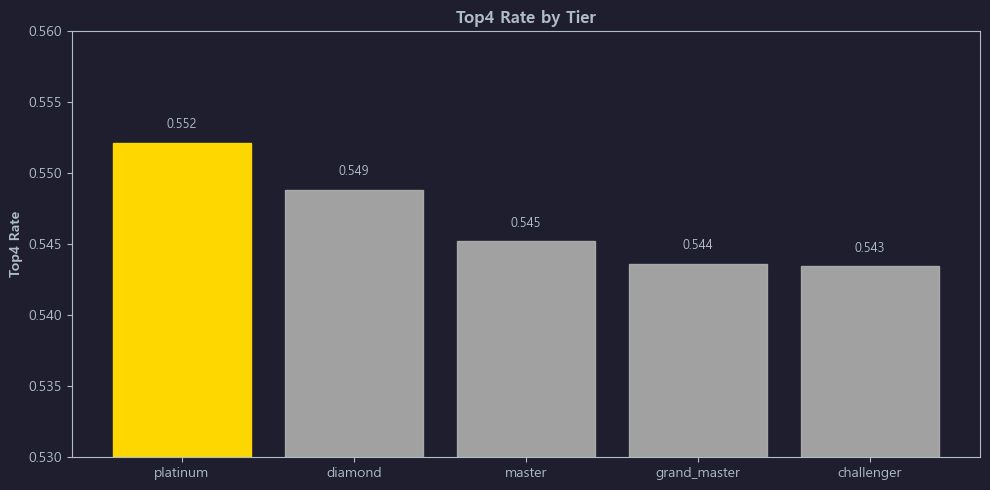

In [183]:
# 시각화 - 그래프 변경 및 강조
fig, ax = plt.subplots(figsize=(10, 5))

# 배경색 설정
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

bars = ax.bar(tier_stats.index, tier_stats.values)

# 최고값 강조
bars[0].set_color('#FFD700')

# 나머지 회색
for i in range(1, len(bars)):
    bars[i].set_color('#b3b3b3e1')

# 글씨색 변경
ax.set_title('Top4 Rate by Tier', color='#b0bec5', fontweight='bold')
ax.set_ylabel('Top4 Rate', color='#b0bec5', fontweight='bold')
ax.tick_params(colors='#b0bec5')
ax.spines[:].set_color('#b0bec5')
plt.xticks(rotation=0)

# 값 표시
for i, v in enumerate(tier_stats.values):
    ax.text(i, v + 0.001, f"{v:.3f}", ha='center', fontsize=9, color='#b0bec5')

ax.set_ylim(0.53, 0.56)

plt.tight_layout()
plt.show()

- 티어 간 차이가 작기 때문에 시각적으로 강조하기 위해 y축 범위를 조정

##### **(1) 카이제곱 독립성 검정**

In [184]:
# df_final의 인덱스 초기화
df_final_2 = df_final.reset_index(drop=True)

# 교차표 생성
ct_tier_top4 = pd.crosstab(df_final_2['user_tier'], df_final_2['top4_flag'])
display(ct_tier_top4)

# Cochran's rule 확인
chi2_tier, p_val_tier, dof_tier, expected_tier = stats.chi2_contingency(ct_tier_top4)

under5_cells_cnts = (expected_tier < 5).sum().sum()
under1_cells_cnts = (expected_tier < 1).sum().sum()
total_cells_cnts = expected_tier.size
under5_cells_pcts = (under5_cells_cnts / total_cells_cnts)*100

print(f"\n[Cochran's rule 점검 결과]")
print(f" 기대빈도가 5보다 낮은 셀이 전체의 {under5_cells_pcts}% 이고, 기대빈도가 1보다 낮은 셀은 {under1_cells_cnts}개이다.")
print(f"따라서 Cochran's rule을 {'만족한다.' if (under5_cells_pcts <= 20 and under1_cells_cnts == 0) else '만족하지 않는다.'}")

top4_flag,False,True
user_tier,,
challenger,162428,193376
diamond,166640,202724
grand_master,169072,201409
master,162076,194308
platinum,143581,177027



[Cochran's rule 점검 결과]
 기대빈도가 5보다 낮은 셀이 전체의 0.0% 이고, 기대빈도가 1보다 낮은 셀은 0개이다.
따라서 Cochran's rule을 만족한다.


In [185]:
# 가설 설정
print("[가설 설정]")
print(f"H₀: 티어와 top4 여부에는 유의한 차이가 없다.")
print(f"H₁: 티어와 top4 여부에는 유의한 차이가 있다.")

# 카이제곱 독립성 검정
print(f'\n[카이제곱 검정 결과]')
print(f'chi2={chi2_tier:.4f}, p={p_val_tier:.4e}, dof={dof_tier}')

# 결론
print(f"\n[결론 (α=0.05)]")
alpha = 0.05
if p_val_tier < alpha:
    print('p-value가 유의수준보다 낮으므로 티어와 top4 여부는 유의미한 관계가 있음')
else:
    print('p-value가 유의수준보다 높으므로 티어와 top4 여부는 유의미한 관계가 없음')

[가설 설정]
H₀: 티어와 top4 여부에는 유의한 차이가 없다.
H₁: 티어와 top4 여부에는 유의한 차이가 있다.

[카이제곱 검정 결과]
chi2=77.1985, p=6.8273e-16, dof=4

[결론 (α=0.05)]
p-value가 유의수준보다 낮으므로 티어와 top4 여부는 유의미한 관계가 있음


In [186]:
from scipy.stats.contingency import association 

# 효과크기 계산 - Cramér's V
r_tier, c_tier = ct_tier_top4.shape
df_star_tier = min(r_tier-1, c_tier-1) # 효과크기 해석 기준을 정하기 위해 필요함

cramers_v_tier = association(ct_tier_top4, method='cramer')

print(f"Cramér's V = {cramers_v_tier:.3f}")
print(f"df* = {df_star_tier}")

# Cramér's V 해석 기준 (df*에 따라 계산)
if cramers_v_tier < (0.1 / np.sqrt(df_star_tier)):
    answer = '효과크기는 매우 작은 편이다.'
elif cramers_v_tier < (0.3 / np.sqrt(df_star_tier)):
    answer = '효과크기는 작은 편이다.'
elif cramers_v_tier < (0.5 / np.sqrt(df_star_tier)):
    answer = '효과크기는 중간인 편이다.'
elif cramers_v_tier >= (0.5 / np.sqrt(df_star_tier)):
    answer = '효과크기는 큰 편이다.'
    
print(f"-> df*의 값이 {df_star_tier}이므로, cramer's 효과크기가 {cramers_v_tier:.3f}라면 {answer}")


Cramér's V = 0.007
df* = 1
-> df*의 값이 1이므로, cramer's 효과크기가 0.007라면 효과크기는 매우 작은 편이다.


In [187]:
# 조정된 잔차 분석 - 어느 셀이 기대와 다른가?
from statsmodels.stats.contingency_tables import Table

print(f"[조정된 잔차]")

table = Table(ct_tier_top4)
std_res_tier = pd.DataFrame(table.standardized_resids, index=ct_tier_top4.index, columns=ct_tier_top4.columns)
display(std_res_tier)

# 조정된 잔차 해석 및 표로 정리
threshold = 1.96

results_tier = []
for top4 in std_res_tier.columns:
    for tier in std_res_tier.index:
        residual_2 = std_res_tier.loc[tier, top4]
        top4_label_2 = 'top4 진입' if top4 == 1 else 'top4 미진입'

        if residual_2 > threshold:
            interpretation2 = '기대빈도보다 실제 빈도가 유의미하게 높음'
        elif residual_2 < -threshold:
            interpretation2 = '기대빈도보다 실제 빈도가 유의미하게 낮음'
        else:
            interpretation2 = '유의미한 차이 없음'

        results_tier.append({
            'user_tier': tier,
            'top4': top4_label_2,
            'residual': round(residual_2, 3),
            '해석': interpretation2
        })

results_df_tier = pd.DataFrame(results_tier)
display(results_df_tier)

[조정된 잔차]


top4_flag,False,True
user_tier,,
challenger,4.106100,-4.106100
diamond,-3.145053,3.145053
grand_master,4.003289,-4.003289
master,1.788468,-1.788468
platinum,-7.045395,7.045395


,user_tier,top4,residual,해석
0,challenger,top4 미진입,4.106,기대빈도보다 실제 빈도가 유의미하게 높음
1,diamond,top4 미진입,-3.145,기대빈도보다 실제 빈도가 유의미하게 낮음
2,grand_master,top4 미진입,4.003,기대빈도보다 실제 빈도가 유의미하게 높음
3,master,top4 미진입,1.788,유의미한 차이 없음
4,platinum,top4 미진입,-7.045,기대빈도보다 실제 빈도가 유의미하게 낮음
5,challenger,top4 진입,-4.106,기대빈도보다 실제 빈도가 유의미하게 낮음
6,diamond,top4 진입,3.145,기대빈도보다 실제 빈도가 유의미하게 높음
7,grand_master,top4 진입,-4.003,기대빈도보다 실제 빈도가 유의미하게 낮음
8,master,top4 진입,-1.788,유의미한 차이 없음
9,platinum,top4 진입,7.045,기대빈도보다 실제 빈도가 유의미하게 높음


[해석 방법]
- 예를 들어 `platinum x top4 진입`이라는 행을 보면 `기대빈도보다 실제 빈도가 유의미하게 높음`이라는 결과가 나왔다. 이는 플래티넘 티어 유저가 top4에 진입한 횟수가 기대값보다 많다는 것이다.
- 반대로 `기대빈도보다 실제 빈도가 유의미하게 낮음`은 해당 티어 유저가 top4에 진입한 횟수가 기대값보다 적다는 것이다.
- 잔차의 절댓값이 클수록 기대빈도와의 차이가 크다는 것을 의미한다.

---
### **3. 픽률이 높은 시너지가 실제로도 효과적인가?**

In [188]:
# 시너지에 따른 선택률과 순방률 계산
synergy_group = df_final.groupby('synergy').agg(
    pick_rate=('synergy', 'count'),
    top4_rate=('top4_flag', 'mean')
)

# 비율로 변환
synergy_group['pick_rate'] = synergy_group['pick_rate'] / synergy_group['pick_rate'].sum()

print(synergy_group.sort_values('pick_rate', ascending=False).head(10))

             pick_rate  top4_rate
synergy                          
Chrono        0.113043   0.548607
Celestial     0.077363   0.538247
Mercenary     0.071677   0.605626
Blaster       0.065140   0.545081
ManaReaver    0.063922   0.560546
Blademaster   0.058631   0.513547
Brawler       0.056986   0.532792
Sorcerer      0.055910   0.536631
Vanguard      0.045766   0.488986
Sniper        0.041199   0.530638


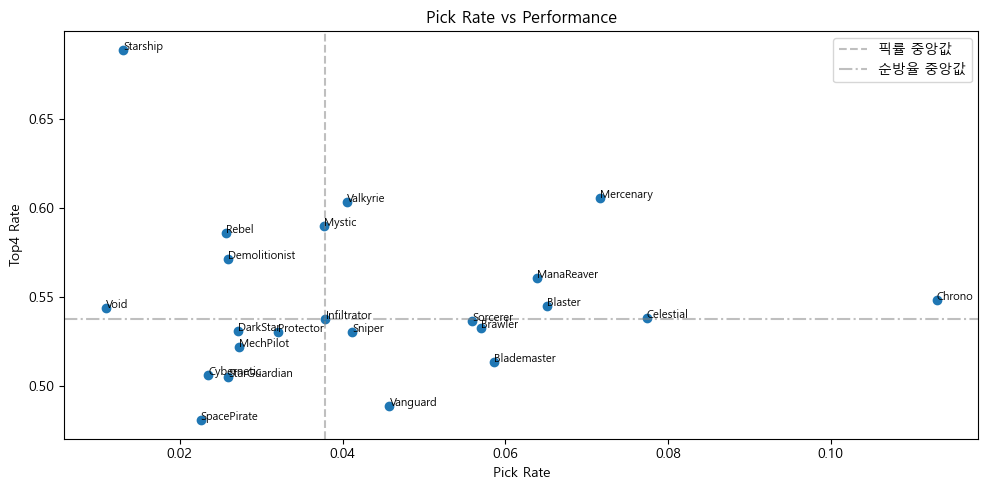

In [189]:
# 시각화 1
plt.figure(figsize=(10, 5))

plt.scatter(synergy_group['pick_rate'], synergy_group['top4_rate'])

for i in synergy_group.index:
    plt.text(
        synergy_group.loc[i, 'pick_rate'],
        synergy_group.loc[i, 'top4_rate'],
        i,
        fontsize=8
    )

# 기준선 (중앙값)
plt.axvline(synergy_group['pick_rate'].median(),
            color='gray', linestyle='--', alpha=0.5, label='픽률 중앙값')
plt.axhline(synergy_group['top4_rate'].median(),
            color='gray', linestyle='-.', alpha=0.5, label='순방율 중앙값')

plt.xlabel('Pick Rate')
plt.ylabel('Top4 Rate')
plt.title('Pick Rate vs Performance')
plt.legend()

plt.tight_layout()
plt.show()

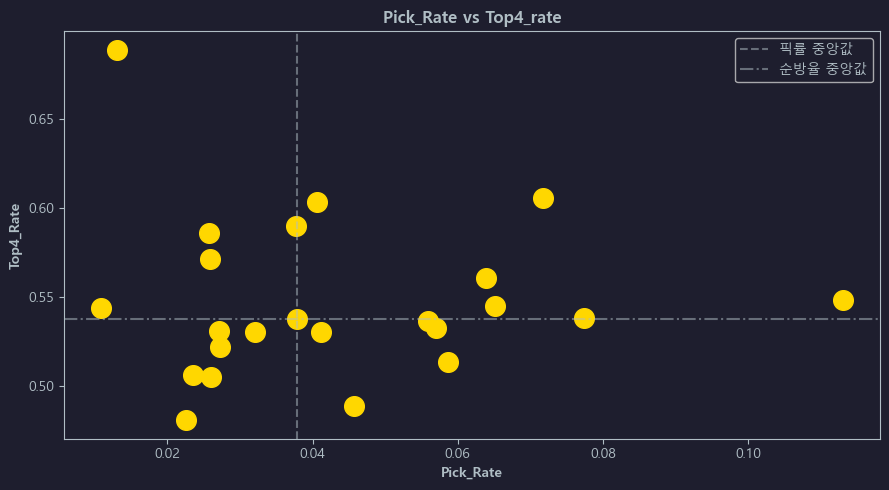

In [190]:
# 시각화 2
fig, ax = plt.subplots(figsize=(9, 5))

# 배경색 설정
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

# 산점도
plt.scatter(
    synergy_group['pick_rate'],
    synergy_group['top4_rate'],
    color="#FFD700",
    s=200
)

# 기준선 (중앙값)
plt.axvline(synergy_group['pick_rate'].median(),
            color='#b0bec5', linestyle='--', alpha=0.5, label='픽률 중앙값')
plt.axhline(synergy_group['top4_rate'].median(),
            color='#b0bec5', linestyle='-.', alpha=0.5, label='순방율 중앙값')

ax.set_xlabel('Pick_Rate', color='#b0bec5', fontweight='bold')
ax.set_ylabel('Top4_Rate', color='#b0bec5', fontweight='bold')
ax.set_title('Pick_Rate vs Top4_rate', color='#b0bec5', fontweight='bold')
ax.tick_params(colors='#b0bec5')
ax.spines[:].set_color('#b0bec5')
ax.legend(facecolor='#1e1e2e', labelcolor='#b0bec5')

plt.tight_layout()
plt.show()

#### **(1) 통계검정**
- 정규성 확인 -> 산점도 -> 상관계수 확인
- 정규성을 확인하여 피어슨 또는 스피어만 상관계수

In [191]:
# 정규성 검정
print('[정규성 검정 - Shapiro-Wilk]')
stat_pick, p_pick = stats.shapiro(synergy_group['pick_rate'])
stat_top4, p_top4 = stats.shapiro(synergy_group['top4_rate'])

print(f'pick_rate: stat={stat_pick:.4f}, p={p_pick:.4e}')
print(f'top4_rate: stat={stat_top4:.4f}, p={p_top4:.4e}')

if p_pick >= alpha and p_top4 >= alpha:
    print('\n✅ 정규성 만족 → 피어슨 상관계수 사용')
else:
    print('\n❌ 정규성 불만족 → 스피어만 상관계수 사용')

[정규성 검정 - Shapiro-Wilk]
pick_rate: stat=0.9136, p=4.8665e-02
top4_rate: stat=0.8973, p=2.2292e-02

❌ 정규성 불만족 → 스피어만 상관계수 사용


In [192]:
# 스피어만 상관계수
    # spearman_r: 상관계수
    # spearman_p: p-value
spearman_r, spearman_p = stats.spearmanr(
    synergy_group['pick_rate'], 
    synergy_group['top4_rate']
)

print(f'[스피어만 상관계수]')
print(f'r = {spearman_r:.4f}, p = {spearman_p:.4e}')

if spearman_p < alpha:
    if spearman_r > 0:
        print('→ 선택률과 순방율은 유의미한 양의 상관관계가 있음')
    else:
        print('→ 선택률과 순방율은 유의미한 음의 상관관계가 있음')
else:
    print('→ 선택률과 순방율은 유의미한 상관관계가 없음')

[스피어만 상관계수]
r = 0.1393, p = 5.2606e-01
→ 선택률과 순방율은 유의미한 상관관계가 없음


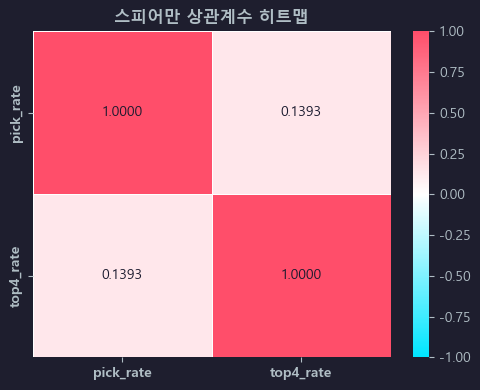

In [193]:
from matplotlib.colors import LinearSegmentedColormap

# 커스텀 cmap 생성
custom_cmap = LinearSegmentedColormap.from_list(
    'custom', ['#00E5FF', '#ffffff', '#FF4E6A']
)

# 스피어만 상관계수 히트맵
spearman_matrix = synergy_group[['pick_rate', 'top4_rate']].corr(method='spearman')

fig, ax = plt.subplots(figsize=(5, 4))
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

sns.heatmap(
    spearman_matrix,
    annot=True,
    fmt='.4f',
    cmap=custom_cmap,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'color': '#1a1a2e'}
)

ax.set_title('스피어만 상관계수 히트맵', color='#b0bec5', fontweight='bold')
ax.tick_params(colors='#b0bec5')
ax.set_xticklabels(ax.get_xticklabels(), fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), fontweight='bold')

# 컬러바 글씨 색상 변경
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors='#b0bec5')  # 컬러바 눈금 색상

plt.tight_layout()
plt.show()